## MARBL diagnostics, compare timeseries of global metrics between multiple cases (only 2-d variables)


In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import os
from glob import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cftime
import pandas as pd
import matplotlib.gridspec as gridspec
from xgcm import Grid
xr.set_options(keep_attrs=True);

### Cases to be compared with major changes

#### All cases are with alpha09d tag

• 003: default POC diss

• 004: 125m POC diss


### Come up with short names for each case

In [2]:
short_names = ['003',
               '004',
              ]

### Define number of years and number of cases

In [3]:
num_cases = len(short_names)
num_years = 86 #max years in any of the runs

### Define cases

In [4]:
sandbox = 'g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37'

case_nums = ['003','004']

user = 'klindsay'

### Define the year range

In [24]:
start_yr = 1
endyr = start_yr + num_years 

### 2-D variable list

In [6]:
variables2d = ['photoC_TOT_zint','photoC_sp_zint','photoC_diat_zint',
               'photoC_diaz_zint','photoC_cocco_zint','CaCO3_PROD_zint',
               'POC_FLUX_100m','x_graze_microzoo_zint',
               'x_graze_mesozoo_zint','IFRAC','FG_CO2','diat_Fe_lim_surf'] 

variables3d = ['DIC','ALK','PO4','NO3','SiO3'] 

coords = {'x':'yh','y':'xh'}


keepthese=['z_l','z_i','time_bounds','time','average_T1', 'average_T2','average_DT'] + variables3d + list(coords.values())

### Get dask going

In [7]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=2,
        memory='25 GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=25GB',
        project='NCGD0011',
        walltime='03:00:00',
        interface='ext',
        log_directory='./dask-logs'
    )

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [8]:
cluster, client = get_ClusterClient()
cluster.scale(12) 
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/33283/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/33283/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.181:41275,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/33283/status,Total threads: 0
Started: Just now,Total memory: 0 B


### Read in all the data

In [9]:
cases_dict = {}

for case_num in case_nums:
    case = sandbox + '.' + case_num
    print(case)

    files = []
    for year in range(start_yr,endyr):
        yr4="{:04d}".format(year)
        #print('doing simulation year', year, '!')
        files.extend(sorted(glob(f'/glade/derecho/scratch/{user}/archive/{case}/ocn/hist/{case}.mom6.h.bgc.z_annual.{yr4}.nc')))
    ds_tmp = xr.open_mfdataset(files,decode_times=True,decode_coords=False, concat_dim='time',combine='nested' )
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keepthese])
    cases_dict[case_num] = ds_tmp

g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37.003
g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37.004


In [10]:
cases_dict.keys()

dict_keys(['003', '004'])

## Get the grid data for MOM6

In [11]:
ds_grid = xr.open_dataset(f'/glade/work/kristenk/cesm_work/mom6_static_files/g.e23b16.TL319_t232.GIAFMARBL.001.mom6.h.static.nc')

In [12]:
lons = ds_grid.geolon
lats = ds_grid.geolat
area = ds_grid.areacello #m2

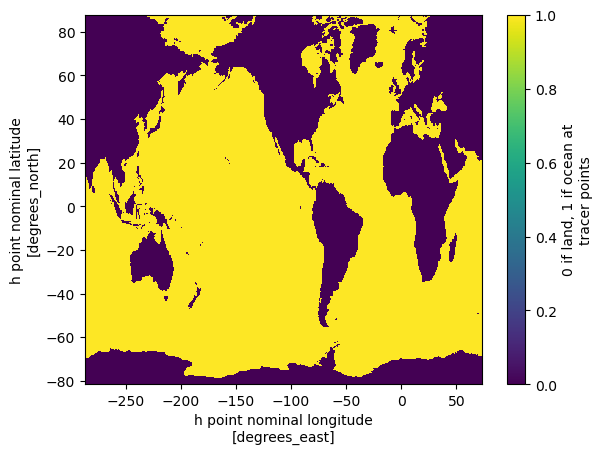

In [13]:
ds_grid.wet.plot()

### make a mean over the last 10 yrs of each model run

In [14]:
mean_case_dict = {}

for case in cases_dict.keys():
    print(case)

    mean_case_dict[case] = cases_dict[case].isel(time=slice(-10, None)).mean(dim="time")

003
004


In [15]:
mean_case_dict.keys()

dict_keys(['003', '004'])

### Make some difference maps

In [16]:



ds_diff = mean_case_dict['004'] - mean_case_dict['003']

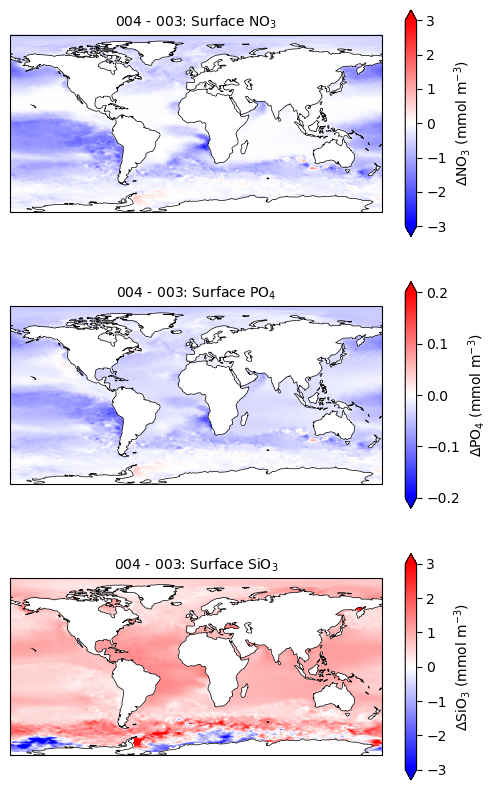

In [20]:
fig = plt.figure(figsize=(6,10))

####################NO3
ax = fig.add_subplot(3,1,1, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: Surface NO$_3$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.NO3.isel(z_l=0), 
                  vmin=-3, vmax=3, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$NO$_3$ (mmol m$^{-3}$)')

####################PO4
ax = fig.add_subplot(3,1,2, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: Surface PO$_4$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.PO4.isel(z_l=0), 
                  vmin=-0.2, vmax=0.2, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$PO$_4$ (mmol m$^{-3}$)')

####################SiO3
ax = fig.add_subplot(3,1,3, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: Surface SiO$_3$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.SiO3.isel(z_l=0), 
                  vmin=-3, vmax=3, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$SiO$_3$ (mmol m$^{-3}$)')


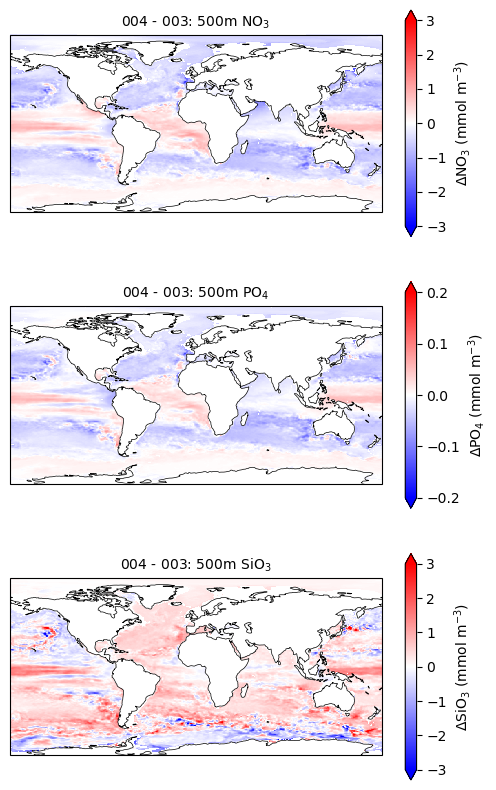

In [22]:
fig = plt.figure(figsize=(6,10))

####################NO3
ax = fig.add_subplot(3,1,1, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: 500m NO$_3$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.NO3.isel(z_l=13), 
                  vmin=-3, vmax=3, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$NO$_3$ (mmol m$^{-3}$)')

####################PO4
ax = fig.add_subplot(3,1,2, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: 500m PO$_4$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.PO4.isel(z_l=13), 
                  vmin=-0.2, vmax=0.2, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$PO$_4$ (mmol m$^{-3}$)')

####################SiO3
ax = fig.add_subplot(3,1,3, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: 500m SiO$_3$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.SiO3.isel(z_l=13), 
                  vmin=-3, vmax=3, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$SiO$_3$ (mmol m$^{-3}$)')


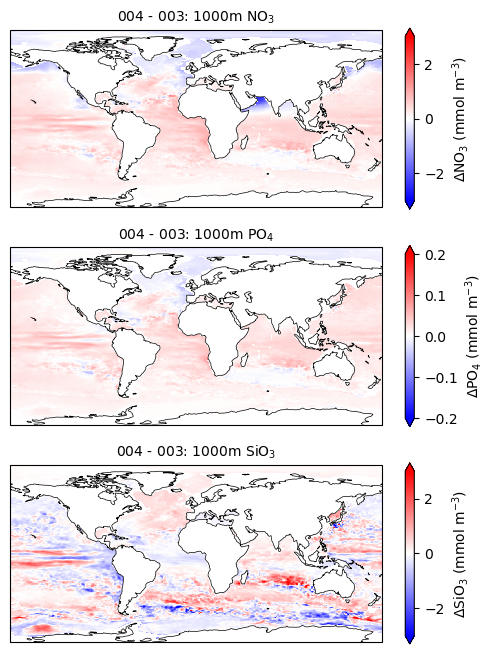

In [23]:
fig = plt.figure(figsize=(6,8))

####################NO3
ax = fig.add_subplot(3,1,1, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: 1000m NO$_3$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.NO3.isel(z_l=18), 
                  vmin=-3, vmax=3, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$NO$_3$ (mmol m$^{-3}$)')

####################PO4
ax = fig.add_subplot(3,1,2, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: 1000m PO$_4$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.PO4.isel(z_l=18), 
                  vmin=-0.2, vmax=0.2, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$PO$_4$ (mmol m$^{-3}$)')


####################SiO3
ax = fig.add_subplot(3,1,3, projection=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('004 - 003: 1000m SiO$_3$', fontsize=10)
pc1=ax.pcolormesh(lons, lats, ds_diff.SiO3.isel(z_l=18), 
                  vmin=-3, vmax=3, cmap='bwr',
                  transform=ccrs.PlateCarree())
cbar1 = fig.colorbar(pc1, ax=ax,extend='both',label='${\Delta}$SiO$_3$ (mmol m$^{-3}$)')

In [25]:
cluster.close()